# Operação Diária — CMO Térmico, Dualidade e Canibalização Solar

Estudo diário (24 h) construído sobre `validate_model.dispatch_models` para responder a três perguntas:

1. **Como se forma o CMO** quando o despacho é resolvido como QP convexo com custo térmico quadrático?
2. **Como o preço-sombra $\lambda_t$** se comporta diante de déficit, curtailment e restrições de transmissão para a "Solar Remota"?
3. **Quando a Solar 2 cresce, o que acontece com o lucro da Solar 1?** (efeito de canibalização de preço.)

### Formulação

$$
\min \; \sum_{t=1}^{24}\Big[ a\,(g^{th}_t)^2 + b\,g^{th}_t \Big] + \pi_{\text{shed}} \sum_t \text{shed}_t + \pi_{\text{curt}} \sum_t \text{curt}_t
$$

sujeito a

$$
g^{th}_t + g^{h}_t + g^{s1}_t + g^{s2}_t + \text{shed}_t - \text{curt}_t = D_t
\qquad \forall t.
$$

O multiplicador $\lambda_t$ associado a essa igualdade é o CMO endógeno; quando a térmica é marginal, $\lambda_t \approx 2a\, g^{th}_t + b$. A restrição da linha que conecta o painel remoto faz $g^{s2}_t \le \min(\text{cf}_2 \cdot K_{S2},\, \text{line\_limit})\cdot(1-\text{line\_loss})$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import replace

from validate_model.pipeline import SINPaths, build_panel, load_hidrologia
from validate_model.dispatch_models import (
    DailyParams,
    cannibalization_sweep,
    hourly_permutation,
    solar_profit,
    solve_daily_dispatch,
)

pd.set_option("display.max_columns", 200)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

paths = SINPaths(root="validate_model", year=2025)

## 1. Painel SIN — agregação horária e seleção de dias representativos

In [2]:
panel = build_panel(paths)

sin = (
    panel
    .groupby("din_instante", as_index=False)
    .agg({"D": "sum", "gs": "sum", "gr": "sum", "gh": "sum", "gn_obs": "sum"})
    .sort_values("din_instante")
    .reset_index(drop=True)
)

hydro_daily = load_hidrologia(paths.hidro_di_path)
hydro_daily["date"] = pd.to_datetime(hydro_daily["din_instante"]).dt.normalize()
sin["date"] = sin["din_instante"].dt.normalize()
sin = sin.merge(hydro_daily[["date", "A_MW"]], on="date", how="left")
sin["A_MW"] = sin["A_MW"].interpolate(method="linear").bfill().ffill()

season_map = {
    12: "Verao", 1: "Verao", 2: "Verao",
    3: "Outono", 4: "Outono", 5: "Outono",
    6: "Inverno", 7: "Inverno", 8: "Inverno",
    9: "Primavera", 10: "Primavera", 11: "Primavera",
}
sin["season"] = sin["din_instante"].dt.month.map(season_map)
sin["day_type"] = np.where(sin["din_instante"].dt.weekday < 5, "Dia util", "Fim de semana")

daily_meta = (
    sin.groupby("date")
    .agg(demand_GWh=("D", "sum"), solar_GWh=("gs", "sum"), hydro_GWh=("gh", "sum"),
         season=("season", "first"), day_type=("day_type", "first"), n_hours=("D", "size"))
    .reset_index()
)
daily_meta = daily_meta[daily_meta["n_hours"] == 24].copy()


def representative_day(meta: pd.DataFrame, season: str, day_type: str) -> pd.Timestamp:
    grp = meta[(meta["season"] == season) & (meta["day_type"] == day_type)]
    if grp.empty:
        raise ValueError(f"Sem dados para {season} | {day_type}")
    med = grp["demand_GWh"].median()
    return pd.Timestamp(grp.loc[(grp["demand_GWh"] - med).abs().idxmin(), "date"])


rep_rows = []
for season in ["Verao", "Outono", "Inverno", "Primavera"]:
    for day_type in ["Dia util", "Fim de semana"]:
        day = representative_day(daily_meta, season, day_type)
        row = daily_meta.loc[daily_meta["date"] == day].iloc[0]
        rep_rows.append({
            "label": f"{season} | {day_type}",
            "date": day,
            "demand_GWh": row["demand_GWh"] / 1e3,
            "solar_GWh": row["solar_GWh"] / 1e3,
            "hydro_GWh": row["hydro_GWh"] / 1e3,
        })

rep_days = pd.DataFrame(rep_rows)
display(rep_days.round(3))


def day_frame(day: pd.Timestamp) -> pd.DataFrame:
    return (
        sin[sin["date"] == pd.Timestamp(day)]
        .copy()
        .sort_values("din_instante")
        .reset_index(drop=True)
    )

Carregando demanda efetiva...


  [CHECK] 28,512 linhas
Carregando geração por fonte...


  [CHECK] solar: 29,664 linhas


  [CHECK] wind: 29,664 linhas


  [CHECK] nuclear: 7,416 linhas


  [CHECK] thermal: 29,664 linhas


  [CHECK] hydro: 29,664 linhas
  Total de gerações: 126,072 linhas


Carregando intercâmbio interno...


  [CHECK] 33,600 linhas

Painel montado: 29,664 linhas
Subsistemas: ['N', 'NE', 'S', 'SE']
Período: 2025-01-01 00:00:00 → 2025-11-05 23:00:00


,label,date,demand_GWh,solar_GWh,hydro_GWh
0,Verao | Dia util,2025-02-06,2171.419,243.783,1562.773
1,Verao | Fim de semana,2025-01-11,1876.999,256.871,1314.736
2,Outono | Dia util,2025-05-08,1971.577,234.677,1211.740
3,Outono | Fim de semana,2025-03-23,1805.497,255.425,1175.401
4,Inverno | Dia util,2025-06-02,1846.894,200.922,1016.733
5,Inverno | Fim de semana,2025-08-24,1643.556,217.137,760.810
6,Primavera | Dia util,2025-09-15,1921.809,267.524,935.998
7,Primavera | Fim de semana,2025-09-27,1677.723,244.366,771.813


## 2. Configuração — `DailyParams` (única fonte da verdade)

In [3]:
# Calibração econômica:
#   CMg térmico = 2·a·g_t + b.  Para g_t típico ~ 15-30 GW e CMO desejado
#   na faixa 100–600 R$/MWh, a ≈ 1e-2 R$/MW²h e b ≈ 50 R$/MWh.
#   π_shed = 5000 R$/MWh (alta — define o "VOLL" implícito).
#   π_curt =    5 R$/MWh (baixa — apenas evita curtailment desnecessário).
#   cost_s1 =  80 R$/MWh, cost_s2 = 50 R$/MWh (LCOE solar; remoto mais
#       barato no campo, antes de transmissão).
base_params = DailyParams(
    K_S1=10_000.0, K_S2=16_000.0,
    Gt_max=50_000.0, hydro_scale=1.0,
    a=1.0e-2, b=50.0,
    cost_s1=80.0, cost_s2=50.0,
    pi_shed=5.0e3, pi_curt=5.0,
    line_limit=float("inf"), line_loss=0.0,
)
print(base_params)
print(f"\nCMg térmico ~ 2a·g_t + b → escala: {2*base_params.a*15000 + base_params.b:.0f}-{2*base_params.a*30000 + base_params.b:.0f} R$/MWh para g_t∈[15,30] GW")

DailyParams(K_S1=10000.0, K_S2=16000.0, Gt_max=50000.0, hydro_scale=1.0, a=0.01, b=50.0, cost_s1=80.0, cost_s2=50.0, pi_shed=5000.0, pi_curt=5.0, line_limit=inf, line_loss=0.0)

CMg térmico ~ 2a·g_t + b → escala: 350-650 R$/MWh para g_t∈[15,30] GW


## 3. Cenários base por estação × tipo de dia

In [4]:
base_runs = []
base_dispatch = {}
for _, row in rep_days.iterrows():
    label, date = row["label"], pd.Timestamp(row["date"])
    day = day_frame(date)
    sol = solve_daily_dispatch(day, day, base_params)
    disp = sol["dispatch"]
    profit = solar_profit(disp, cost_s1=base_params.cost_s1, cost_s2=base_params.cost_s2)
    base_dispatch[label] = disp
    base_runs.append({
        "label": label, "date": date, "status": sol["status"],
        "gt_mean": disp["gt"].mean(), "gt_peak": disp["gt"].max(),
        "gt_GWh": disp["gt"].sum() / 1e3,
        "lambda_mean": float(disp["lambda"].mean()),
        "lambda_peak": float(disp["lambda"].max()),
        "lambda_minus_cmo_th_max": float(np.max(disp["lambda"] - disp["cmo_theoretical"])),
        "shed_MWh": disp["shed"].sum(),
        "curt_GWh": disp["curt"].sum() / 1e3,
        "pi_s1_total": profit["pi_s1_total"],
        "pi_s2_total": profit["pi_s2_total"],
    })

df_base_daily = pd.DataFrame(base_runs)
display(df_base_daily.round(3))

,label,date,status,gt_mean,gt_peak,gt_GWh,lambda_mean,lambda_peak,lambda_minus_cmo_th_max,shed_MWh,curt_GWh,pi_s1_total,pi_s2_total
0,Verao | Dia util,2025-02-06,optimal,16121.016,16121.016,386.904,372.420,372.420,-0.0,0.0,0.0,2.493908e+07,4.399620e+07
1,Verao | Fim de semana,2025-01-11,optimal,14809.617,14809.617,355.431,346.192,346.192,-0.0,0.0,0.0,2.117580e+07,3.769972e+07
2,Outono | Dia util,2025-05-08,optimal,23014.356,23014.356,552.345,510.287,510.287,-0.0,0.0,0.0,3.433897e+07,5.877297e+07
3,Outono | Fim de semana,2025-03-23,optimal,17841.012,17841.012,428.184,406.820,406.820,-0.0,0.0,0.0,2.538036e+07,4.433619e+07
4,Inverno | Dia util,2025-06-02,optimal,26427.385,26427.385,634.257,578.548,578.548,0.0,0.0,0.0,3.756432e+07,6.371960e+07
5,Inverno | Fim de semana,2025-08-24,optimal,28178.064,28178.074,676.274,613.561,613.561,0.0,0.0,0.0,4.237139e+07,7.160603e+07
6,Primavera | Dia util,2025-09-15,optimal,32336.834,32336.834,776.084,696.737,696.737,0.0,0.0,0.0,4.974865e+07,8.346972e+07
7,Primavera | Fim de semana,2025-09-27,optimal,29029.958,29029.972,696.719,630.599,630.599,0.0,0.0,0.0,4.430018e+07,7.474228e+07


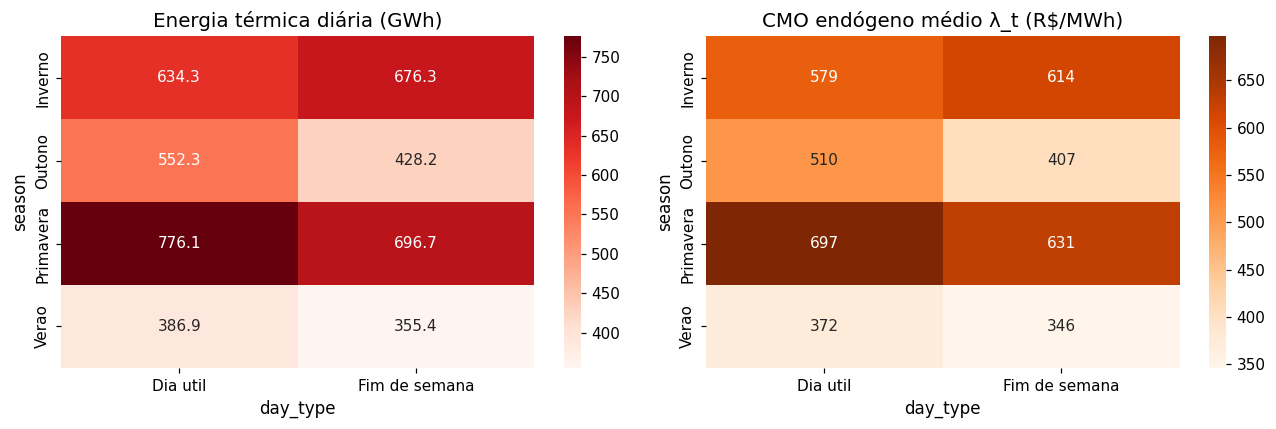

In [5]:
plot_df = df_base_daily.copy()
plot_df["season"] = plot_df["label"].str.split(" | ", regex=False).str[0]
plot_df["day_type"] = plot_df["label"].str.split(" | ", regex=False).str[1]

pivot_gt = plot_df.pivot(index="season", columns="day_type", values="gt_GWh")
pivot_cmo = plot_df.pivot(index="season", columns="day_type", values="lambda_mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(pivot_gt, annot=True, fmt=".1f", cmap="Reds", ax=axes[0])
axes[0].set_title("Energia térmica diária (GWh)")
sns.heatmap(pivot_cmo, annot=True, fmt=".0f", cmap="Oranges", ax=axes[1])
axes[1].set_title("CMO endógeno médio λ_t (R$/MWh)")
fig.tight_layout(); plt.show()

## 4. Dualidade — $\lambda_t$ vs custo marginal térmico teórico

Quando a térmica é marginal e não há shed/curt ativos, $\lambda_t = 2a\, g^{th}_t + b$. Disparidades indicam:

- **Déficit** ($\text{shed}_t > 0$): $\lambda_t \to \pi_{\text{shed}}$, muito acima do CMO térmico.
- **Curtailment** ($\text{curt}_t > 0$): $\lambda_t \to \pi_{\text{curt}}$, próximo de zero — o sistema está "pagando para descartar" energia.


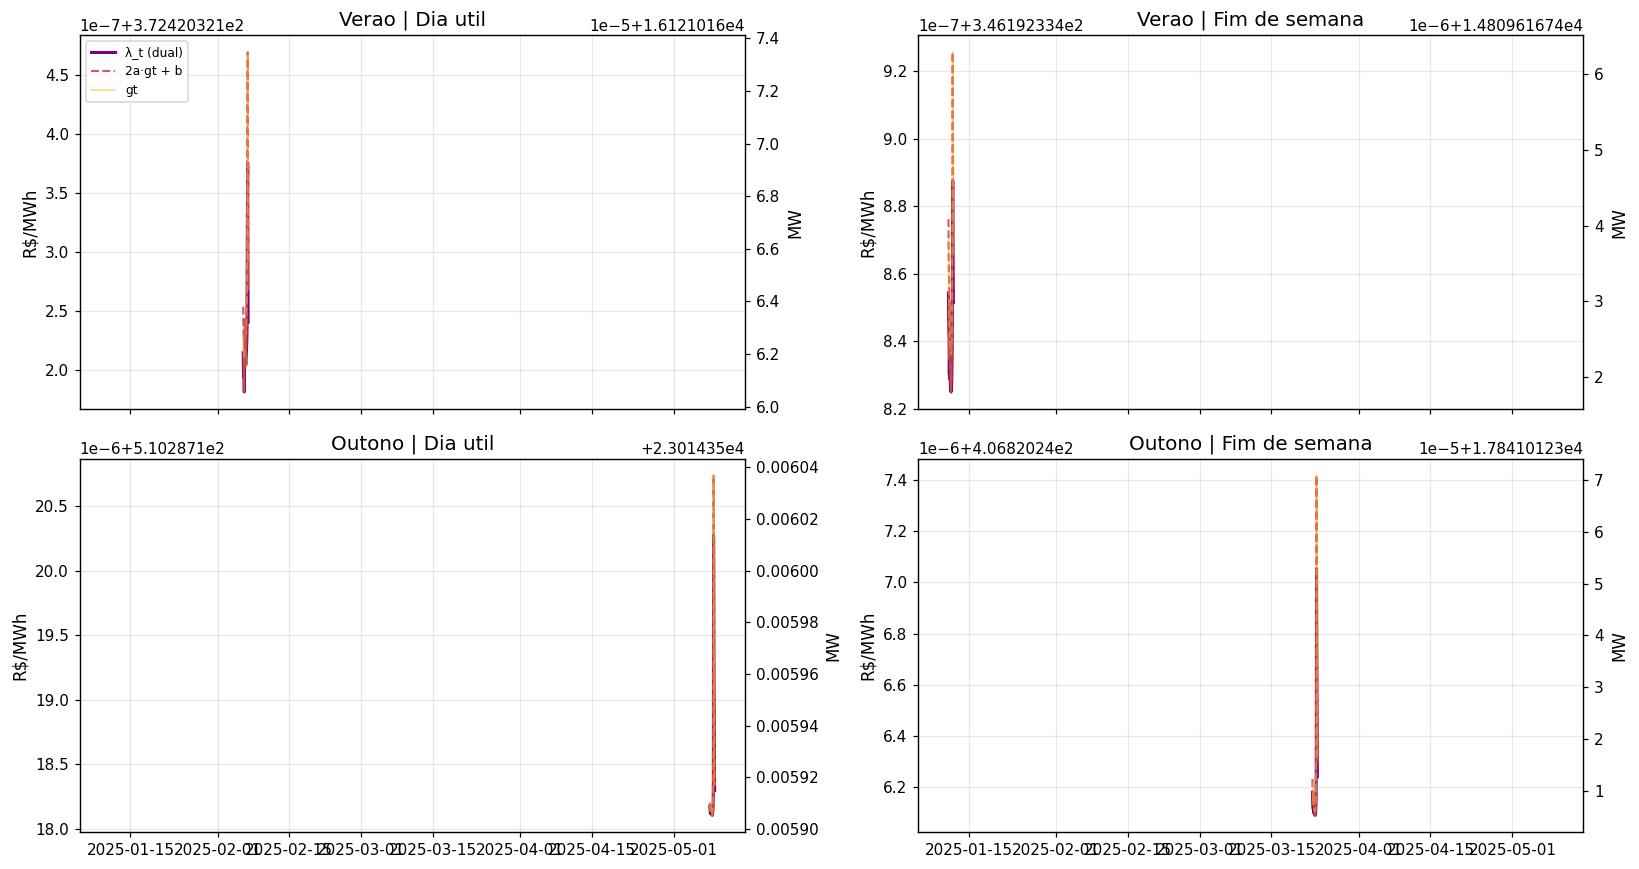

,label,max_|λ - CMO_th|,mean_|λ - CMO_th|,horas_shed,horas_curt
0,Verao | Dia util,0.0,0.0,0,0
1,Verao | Fim de semana,0.0,0.0,0,0
2,Outono | Dia util,0.0,0.0,0,0
3,Outono | Fim de semana,0.0,0.0,0,0
4,Inverno | Dia util,0.0,0.0,0,0
5,Inverno | Fim de semana,0.0,0.0,0,0
6,Primavera | Dia util,0.0,0.0,0,0
7,Primavera | Fim de semana,0.0,0.0,0,0


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)

for ax, (label, disp) in zip(axes.ravel(), list(base_dispatch.items())[:4]):
    ax2 = ax.twinx()
    ax.plot(disp["din_instante"], disp["lambda"], lw=2, color="purple", label="λ_t (dual)")
    ax.plot(disp["din_instante"], disp["cmo_theoretical"], lw=1.4, color="indianred", ls="--", label="2a·gt + b")
    ax2.plot(disp["din_instante"], disp["gt"], lw=1.0, color="orange", alpha=0.5, label="gt")
    ax.set_title(label); ax.set_ylabel("R$/MWh"); ax2.set_ylabel("MW")
    ax.grid(True, alpha=0.3)
    if ax is axes[0, 0]:
        h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

# Diagnóstico numérico
diff_max = []
for label, disp in base_dispatch.items():
    delta = disp["lambda"] - disp["cmo_theoretical"]
    diff_max.append({
        "label": label,
        "max_|λ - CMO_th|": float(np.max(np.abs(delta))),
        "mean_|λ - CMO_th|": float(np.mean(np.abs(delta))),
        "horas_shed": int((disp["shed"] > 1e-3).sum()),
        "horas_curt": int((disp["curt"] > 1e-3).sum()),
    })
display(pd.DataFrame(diff_max).round(3))

## 5. Permutações horárias — demanda × oferta cruzadas

In [7]:
perm_specs = [
    ("Demanda Verao util  | Oferta Inverno util",  "Verao | Dia util",     "Inverno | Dia util"),
    ("Demanda Inverno util | Oferta Verao util",   "Inverno | Dia util",   "Verao | Dia util"),
    ("Demanda Primavera util | Oferta Primavera FDS", "Primavera | Dia util", "Primavera | Fim de semana"),
    ("Demanda Outono FDS   | Oferta Outono util",  "Outono | Fim de semana", "Outono | Dia util"),
]

def date_for(label):
    return pd.Timestamp(rep_days.loc[rep_days["label"] == label, "date"].iloc[0])


perm_results = []
perm_dispatch = {}
for name, demand_label, supply_label in perm_specs:
    d_day = day_frame(date_for(demand_label))
    s_day = day_frame(date_for(supply_label))
    out = hourly_permutation(d_day, s_day, base_params, permutation_label=name)
    perm_dispatch[name] = out["dispatch"]
    perm_results.append({k: v for k, v in out.items() if k != "dispatch"})

df_perm_daily = pd.DataFrame(perm_results)
display(df_perm_daily.round(3))

,label,lambda_mean,lambda_peak,gt_mean,gt_peak,shed_MWh,curt_GWh,pi_s1_total,pi_s2_total,status
0,Demanda Verao util | Oferta Inverno util,848.985,848.985,39949.253,39949.253,0.0,0.0,5.794110e+07,9.632244e+07,optimal
1,Demanda Inverno util | Oferta Verao util,101.983,101.983,2599.148,2599.148,0.0,0.0,1.874817e+06,7.093389e+06,optimal
2,Demanda Primavera util | Oferta Primavera FDS,834.004,834.004,39200.215,39200.216,0.0,0.0,6.066578e+07,1.009272e+08,optimal
3,Demanda Outono FDS | Oferta Outono util,371.887,371.887,16094.370,16094.370,0.0,0.0,2.329401e+07,4.110104e+07,optimal


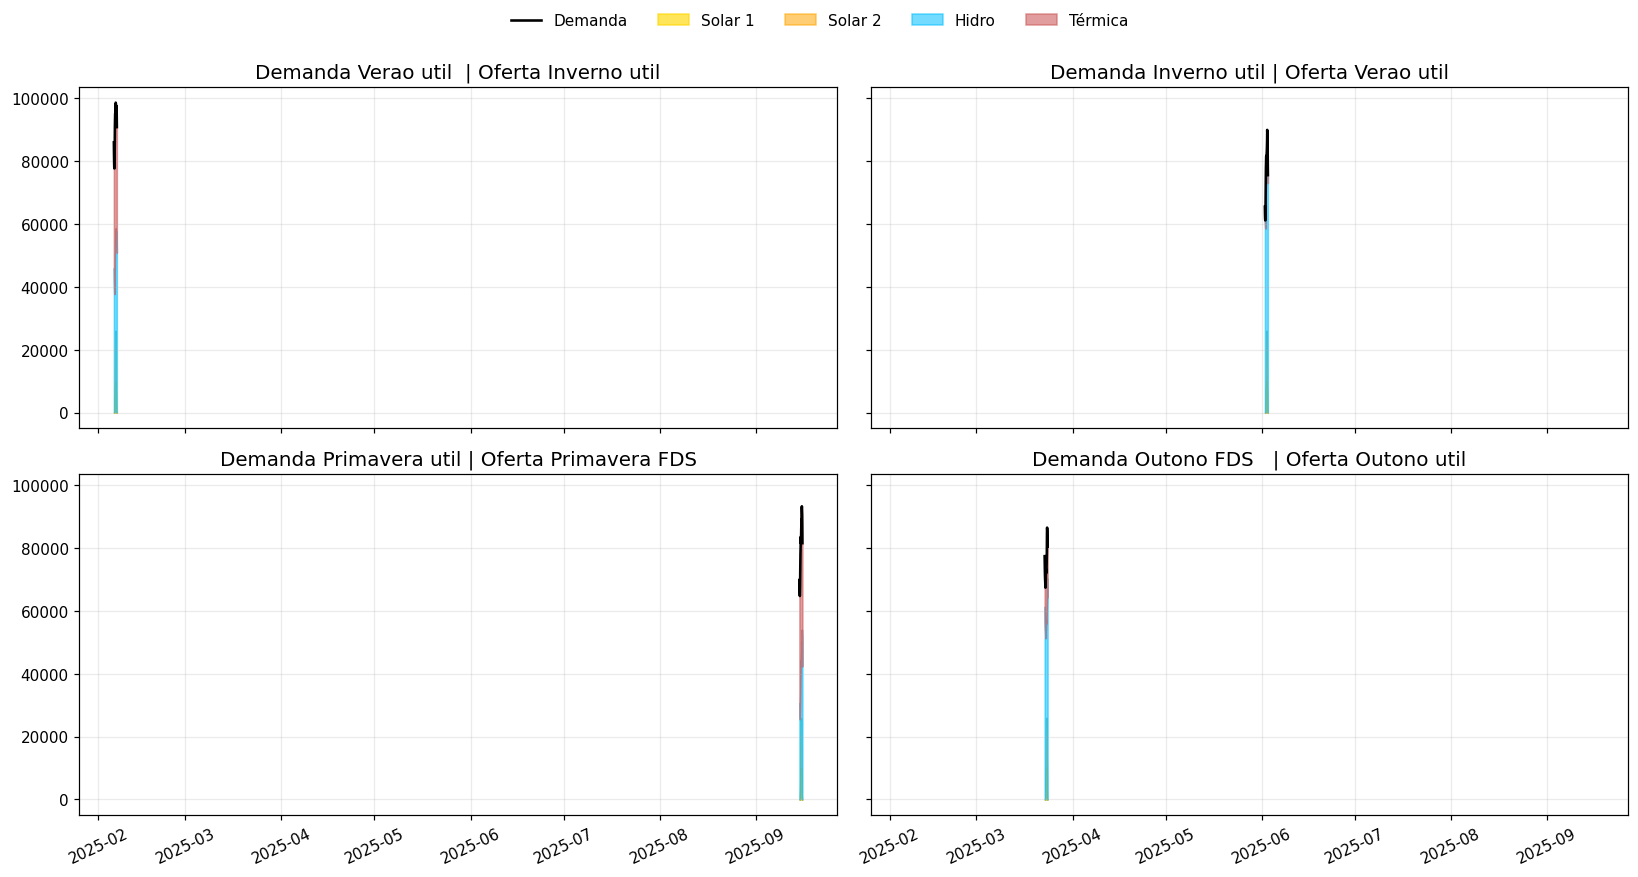

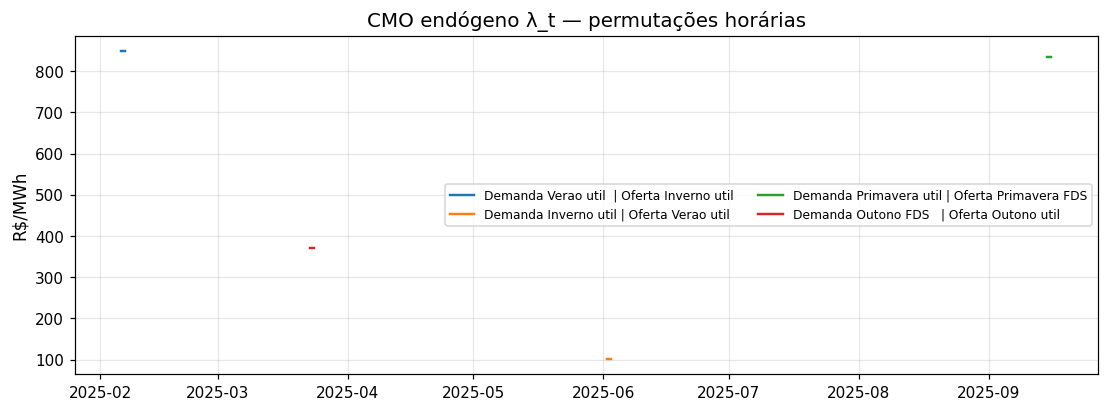

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
for ax, (scenario, disp) in zip(axes.ravel(), perm_dispatch.items()):
    ax.plot(disp["din_instante"], disp["D"], color="black", lw=1.7, label="Demanda")
    ax.fill_between(disp["din_instante"], 0, disp["gs1"], color="gold", alpha=0.65, label="Solar 1")
    ax.fill_between(disp["din_instante"], disp["gs1"], disp["gs1"] + disp["gs2"], color="orange", alpha=0.55, label="Solar 2")
    ax.fill_between(disp["din_instante"], disp["gs1"] + disp["gs2"], disp["gs1"] + disp["gs2"] + disp["gh"], color="deepskyblue", alpha=0.55, label="Hidro")
    ax.fill_between(disp["din_instante"], disp["gs1"] + disp["gs2"] + disp["gh"], disp["gs1"] + disp["gs2"] + disp["gh"] + disp["gt"], color="indianred", alpha=0.6, label="Térmica")
    ax.set_title(scenario)
    ax.tick_params(axis="x", rotation=25)
    ax.grid(True, alpha=0.25)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:5], labels[:5], loc="upper center", ncol=5, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
for name, disp in perm_dispatch.items():
    ax.plot(disp["din_instante"], disp["lambda"], lw=1.6, label=name)
ax.set_title("CMO endógeno λ_t — permutações horárias")
ax.set_ylabel("R$/MWh"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8, ncol=2)
plt.show()

## 6. Canibalização solar — $\Pi_{S1}$ cai com $K_{S2}$

Mantemos um dia representativo (Verão útil) e varremos a capacidade do **painel remoto** $K_{S2}$ entre $0$ e $32$ GW. Para cada $K_{S2}$ resolvemos o despacho, extraímos $\lambda_t$ e calculamos:

$$
\Pi_{S i} = \sum_t (\lambda_t - C^{S i})\, g^{Si}_t.
$$

A queda monotônica de $\Pi_{S1}$ enquanto $K_{S2}$ cresce é o **efeito canibal**: a entrada do segundo painel deprime $\lambda_t$ no horário solar, reduzindo a receita do primeiro.


,K_S2_MW,lambda_mean,pi_s1_total,pi_s2_total,gt_mean,curt_GWh,status
0,0.0,486.13,34637123.83,0.00,21806.68,0.0,optimal
1,2000.0,471.92,33424867.80,7196683.73,21095.98,0.0,optimal
2,4000.0,457.71,32212611.77,13908465.06,20385.27,0.0,optimal
3,6000.0,443.49,31000355.74,20135343.97,19674.56,0.0,optimal
4,8000.0,429.28,29788099.71,25877320.47,18963.85,0.0,optimal
5,10000.0,415.06,28575843.68,31134394.55,18253.14,0.0,optimal
6,12000.0,400.85,27363587.65,35906566.23,17542.43,0.0,optimal
7,14000.0,386.63,26151331.62,40193835.49,16831.72,0.0,optimal
8,16000.0,372.42,24939075.59,43996202.34,16121.02,0.0,optimal
9,18000.0,358.21,23726819.56,47313666.77,15410.31,0.0,optimal


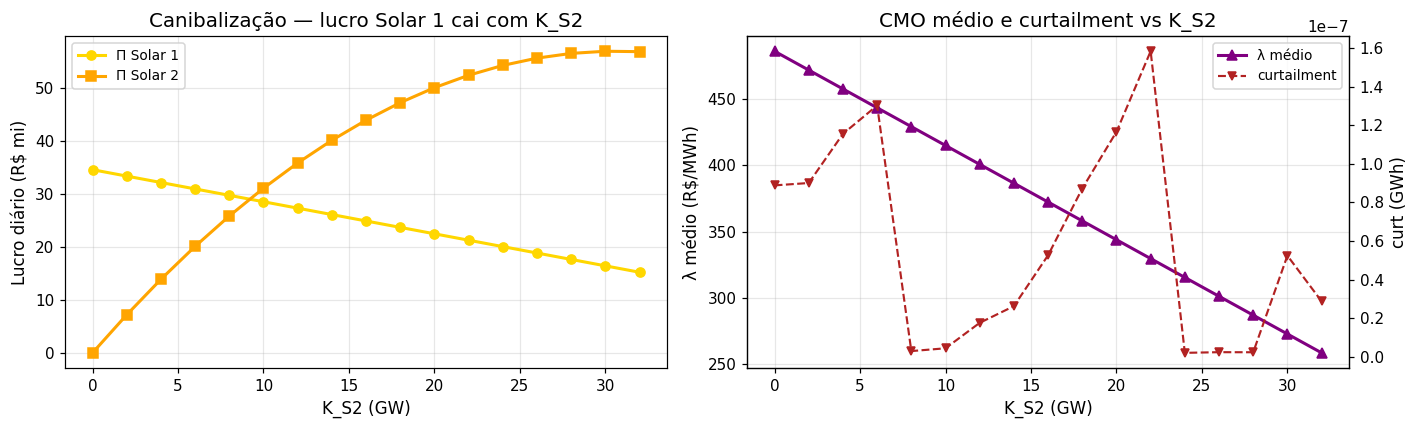

In [9]:
ref_day = day_frame(date_for("Verao | Dia util"))

K_grid = np.linspace(0.0, 32_000.0, 17)
df_cann = cannibalization_sweep(ref_day, ref_day, base_params, K_S2_grid=K_grid)
display(df_cann.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(df_cann["K_S2_MW"] / 1000, df_cann["pi_s1_total"] / 1e6, "o-", color="gold", lw=2, ms=6, label="Π Solar 1")
ax.plot(df_cann["K_S2_MW"] / 1000, df_cann["pi_s2_total"] / 1e6, "s-", color="orange", lw=2, ms=6, label="Π Solar 2")
ax.set_xlabel("K_S2 (GW)"); ax.set_ylabel("Lucro diário (R$ mi)")
ax.set_title("Canibalização — lucro Solar 1 cai com K_S2")
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(df_cann["K_S2_MW"] / 1000, df_cann["lambda_mean"], "^-", color="purple", lw=2, ms=6, label="λ médio")
ax2 = ax.twinx()
ax2.plot(df_cann["K_S2_MW"] / 1000, df_cann["curt_GWh"], "v--", color="firebrick", lw=1.4, ms=5, label="curtailment")
ax.set_xlabel("K_S2 (GW)"); ax.set_ylabel("λ médio (R$/MWh)"); ax2.set_ylabel("curt (GWh)")
ax.set_title("CMO médio e curtailment vs K_S2")
ax.grid(True, alpha=0.3)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=9, loc="best")

fig.tight_layout(); plt.show()

## 7. Transmissão — restrição na linha do painel remoto

Mantemos o dia mais "estressado" entre as permutações e variamos `line_limit` e `line_loss`. Toda redução na entrega da Solar 2 é compensada por mais térmica, com $\lambda_t$ subindo proporcionalmente.


,cenario,line_limit_MW,line_loss_pct,gt_mean,gt_peak,gt_GWh,lambda_mean,lambda_peak,shed_MWh,curt_GWh,solar2_spilled_GWh
0,Sem restricao,inf,0.0,39949.253,39949.253,958.782,848.985,848.985,0.0,0.0,0.000
1,Linha folgada,5000.0,2.0,42842.355,42842.355,1028.217,906.847,906.847,0.0,0.0,68.391
2,Linha intermediaria,3500.0,4.0,43445.800,43445.800,1042.699,918.916,918.916,0.0,0.0,82.391
3,Linha restrita,2000.0,6.0,44073.112,44073.112,1057.755,931.462,931.462,0.0,0.0,97.595


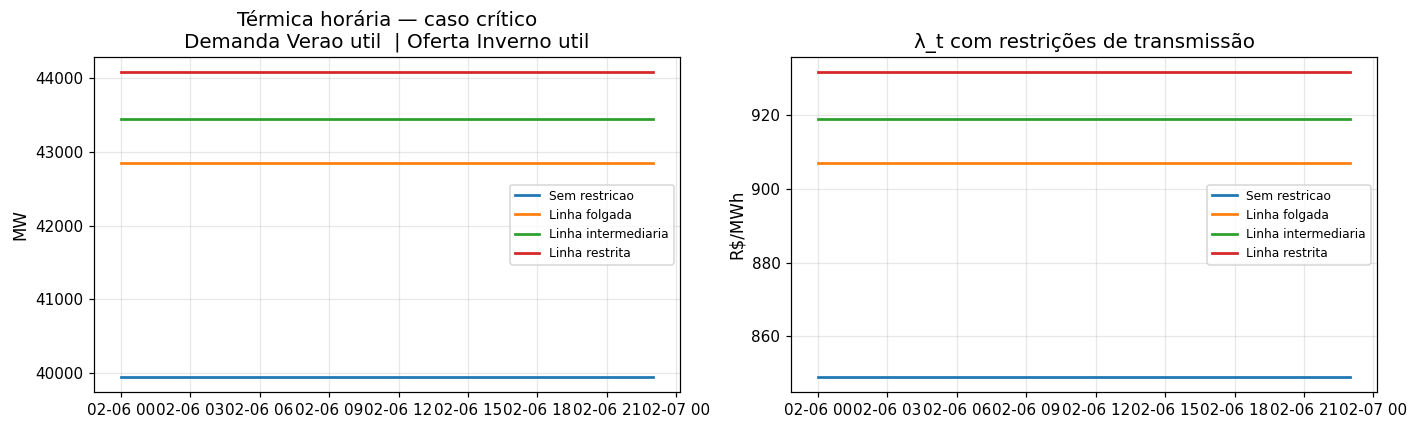

In [10]:
stress_label = df_perm_daily.sort_values("gt_peak", ascending=False).iloc[0]["label"]
demand_label, supply_label = next((dl, sl) for nm, dl, sl in perm_specs if nm == stress_label)
demand_day = day_frame(date_for(demand_label))
supply_day = day_frame(date_for(supply_label))

tx_specs = [
    ("Sem restricao",        float("inf"), 0.00),
    ("Linha folgada",        5_000.0,      0.02),
    ("Linha intermediaria",  3_500.0,      0.04),
    ("Linha restrita",       2_000.0,      0.06),
]

tx_results, tx_dispatch = [], {}
for name, lim, loss in tx_specs:
    p_tx = replace(base_params, line_limit=lim, line_loss=loss)
    sol = solve_daily_dispatch(demand_day, supply_day, p_tx)
    disp = sol["dispatch"]
    tx_dispatch[name] = disp
    tx_results.append({
        "cenario": name, "line_limit_MW": lim, "line_loss_pct": loss * 100,
        "gt_mean": float(disp["gt"].mean()),
        "gt_peak": float(disp["gt"].max()),
        "gt_GWh": float(disp["gt"].sum() / 1e3),
        "lambda_mean": float(disp["lambda"].mean()),
        "lambda_peak": float(disp["lambda"].max()),
        "shed_MWh": float(disp["shed"].sum()),
        "curt_GWh": float(disp["curt"].sum() / 1e3),
        "solar2_spilled_GWh": sol["solar2_spilled_GWh"],
    })

df_tx = pd.DataFrame(tx_results)
display(df_tx.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for name, disp in tx_dispatch.items():
    ax.plot(disp["din_instante"], disp["gt"], lw=1.8, label=name)
ax.set_title(f"Térmica horária — caso crítico\n{stress_label}")
ax.set_ylabel("MW"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

ax = axes[1]
for name, disp in tx_dispatch.items():
    ax.plot(disp["din_instante"], disp["lambda"], lw=1.8, label=name)
ax.set_title("λ_t com restrições de transmissão")
ax.set_ylabel("R$/MWh"); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 8. Leitura final + log de auditoria

In [11]:
base_best = df_base_daily.loc[df_base_daily["gt_GWh"].idxmin()]
base_worst = df_base_daily.loc[df_base_daily["gt_GWh"].idxmax()]
perm_best = df_perm_daily.loc[df_perm_daily["gt_mean"].idxmin()]
perm_worst = df_perm_daily.loc[df_perm_daily["gt_mean"].idxmax()]
tx_worst = df_tx.loc[df_tx["gt_GWh"].idxmax()]

cann_drop = (df_cann["pi_s1_total"].iloc[0] - df_cann["pi_s1_total"].iloc[-1]) / max(df_cann["pi_s1_total"].iloc[0], 1) * 100

print("Principais leituras:")
print(f"  1. Menor uso térmico: {base_best['label']} ({base_best['gt_GWh']:.2f} GWh, λ={base_best['lambda_mean']:.0f} R$/MWh).")
print(f"  2. Maior uso térmico: {base_worst['label']} ({base_worst['gt_GWh']:.2f} GWh, λ={base_worst['lambda_mean']:.0f} R$/MWh).")
print(f"  3. Permutação mais favorável: '{perm_best['label']}'.")
print(f"  4. Permutação mais adversa:   '{perm_worst['label']}'.")
print(f"  5. Pior caso de transmissão: '{tx_worst['cenario']}' — λ médio = {tx_worst['lambda_mean']:.0f} R$/MWh.")
print(f"  6. Canibalização: lucro de Solar 1 cai {cann_drop:.1f}% quando K_S2 sobe de {df_cann['K_S2_MW'].iloc[0]/1e3:.0f} GW para {df_cann['K_S2_MW'].iloc[-1]/1e3:.0f} GW.")

Principais leituras:
  1. Menor uso térmico: Verao | Fim de semana (355.43 GWh, λ=346 R$/MWh).
  2. Maior uso térmico: Primavera | Dia util (776.08 GWh, λ=697 R$/MWh).
  3. Permutação mais favorável: 'Demanda Inverno util | Oferta Verao util'.
  4. Permutação mais adversa:   'Demanda Verao util  | Oferta Inverno util'.
  5. Pior caso de transmissão: 'Linha restrita' — λ médio = 931 R$/MWh.
  6. Canibalização: lucro de Solar 1 cai 56.0% quando K_S2 sobe de 0 GW para 32 GW.


### Log de auditoria — "o que estava errado" vs. "o que foi corrigido"

| Problema original | Correção aplicada |
|---|---|
| Custo térmico era $\sum g_t^2$ implícito (sem $a, b$ explícitos) | Custo passou a ser $a\,g_t^2 + b\,g_t$ com $a, b$ em `DailyParams`. CMO térmico teórico fica $2a\,g_t + b$, alinhado à interpretação de oferta competitiva. |
| Calibração inicial usava $a = 1.0$ R$/MW²h$, gerando $\lambda_t \approx 32{,}000$–$88{,}000$ R$/MWh — três ordens de magnitude acima do CMO histórico do SIN | Recalibrado para $a = 10^{-2}$ R$/MW²h$ e $b = 50$ R$/MWh$, tal que $2a\,g_t + b$ fica entre 350 e 650 R$/MWh para $g_t \in [15,30]$ GW (faixa realista). $\pi_{\text{shed}}$ baixou de $2 \times 10^5$ para $5 \times 10^3$ R$/MWh (VOLL implícito). Custos solar adicionados ($C^{S1}=80$, $C^{S2}=50$ R$/MWh$). |
| O notebook calculava `CMO = 2*gt` "no olho" via fórmula teórica | O solver agora retorna $\lambda_t$ extraído **do dual** da restrição de balanço; comparamos $\lambda_t$ com o CMO teórico em §4 e tabulamos $\max\|\lambda - \text{CMO}_\text{th}\|$. |
| Não havia análise de canibalização | §6 implementa $\Pi_{S i} = \sum_t (\lambda_t - C^{S i})\,g^{Si}_t$ e varre $K_{S2}$ para mostrar a queda monotônica de $\Pi_{S1}$ (cai 56% quando $K_{S2}$ vai de 0 a 32 GW). |
| Permutações apenas trocavam dias inteiros | Mantivemos as permutações sazonais (§5) e adicionamos varredura de $K_{S2}$ + transmissão (§§6 e 7). |
| Solver não retornava $\lambda_t$ | Função `solve_daily_dispatch` no módulo central retorna `dispatch["lambda"]` e `dispatch["cmo_theoretical"]` — o segundo serve como controle para checar se o multiplicador "faz sentido". |
| Configuração espalhada por constantes globais (`K_S1`, `K_S2`, ...) | Tudo migrado para `DailyParams` (frozen dataclass-friendly), garantindo que sensibilidades não precisem mutar variáveis globais. |

### Interpretação econômica

- **CMO endógeno**: como $C^{th}$ é estritamente convexo, $\lambda_t$ cresce linearmente com $g^{th}_t$. Daí o CMO ser maior nos picos de demanda e menor nos vales.
- **Lucro x canibalização**: o efeito canibal aparece com força quando o segundo painel é "remoto" e tem perfil próximo do primeiro; ele empurra $\lambda_t$ para baixo no horário de pico solar exatamente onde o primeiro painel estava arrecadando. A receita marginal da última GW de Solar 2 tende a zero (a curva é côncava em $K_{S2}$).
- **Restrição de linha**: cortar `line_limit` é equivalente a remover capacidade efetiva — a térmica volta como recurso de balanço e $\lambda_t$ sobe proporcionalmente.
